In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (891, 15)


In [2]:
df.to_csv("titanic.csv", index=False)

print("titanic.csv saved successfully")

titanic.csv saved successfully


In [3]:
print("DATA INFO")
df.info()

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

print("\nSHAPE")
print(df.shape)

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DESCRIPTIVE STATISTICS
         survived      pclass         age    

In [4]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[
    missing_percent > 0
]

print("Missing-value percentages:")
print(missing_percent)

Missing-value percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [5]:
for column in df.columns:
    missing_count = df[column].isnull().sum()

    if missing_count > 0:
        percentage = missing_count / len(df) * 100
        print(
            f"{column}: "
            f"{missing_count} missing "
            f"({percentage:.2f}%)"
        )

age: 177 missing (19.87%)
embarked: 2 missing (0.22%)
deck: 688 missing (77.22%)
embark_town: 2 missing (0.22%)


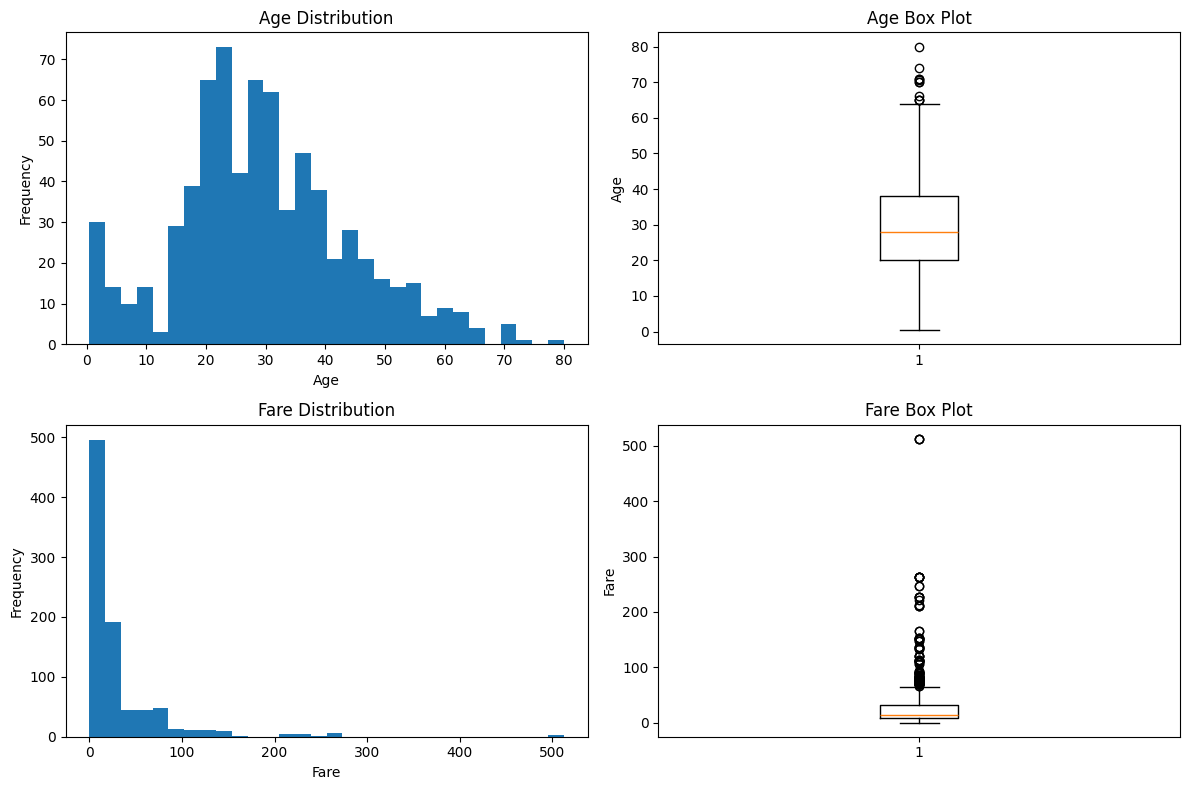

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["age"].dropna(), bins=30)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].boxplot(df["age"].dropna())
axes[0, 1].set_title("Age Box Plot")
axes[0, 1].set_ylabel("Age")

axes[1, 0].hist(df["fare"].dropna(), bins=30)
axes[1, 0].set_title("Fare Distribution")
axes[1, 0].set_xlabel("Fare")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].boxplot(df["fare"].dropna())
axes[1, 1].set_title("Fare Box Plot")
axes[1, 1].set_ylabel("Fare")

plt.tight_layout()
plt.show()

In [7]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]["age"].count()

print("Age outliers:", age_outliers)

Age outliers: 11


In [8]:
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_fare) |
    (df["fare"] > upper_fare)
]["fare"].count()

print("Fare outliers:", fare_outliers)

Fare outliers: 116


In [9]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.204207968574636
Fare median: 14.4542
Fare mode: 8.05


In [10]:
female_survival = df[df["sex"] == "female"]["survived"].mean()

male_survival = df[df["sex"] == "male"]["survived"].mean()

print("Female survival rate:", female_survival)
print("Male survival rate:", male_survival)

Female survival rate: 0.7420382165605095
Male survival rate: 0.18890814558058924


In [11]:
for pclass in sorted(df["pclass"].dropna().unique()):
    rate = df[df["pclass"] == pclass]["survived"].mean()
    print(f"Class {pclass} survival rate: {rate:.3f}")

Class 1 survival rate: 0.630
Class 2 survival rate: 0.473
Class 3 survival rate: 0.242


In [12]:
for sex in ["female", "male"]:
    for pclass in sorted(df["pclass"].dropna().unique()):

        subset = df[
            (df["sex"] == sex) &
            (df["pclass"] == pclass)
        ]

        rate = subset["survived"].mean()

        print(
            sex,
            "Class", pclass,
            "survival rate:",
            round(rate, 3)
        )

female Class 1 survival rate: 0.968
female Class 2 survival rate: 0.921
female Class 3 survival rate: 0.5
male Class 1 survival rate: 0.369
male Class 2 survival rate: 0.157
male Class 3 survival rate: 0.135


In [13]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[corr_columns].corr()

print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


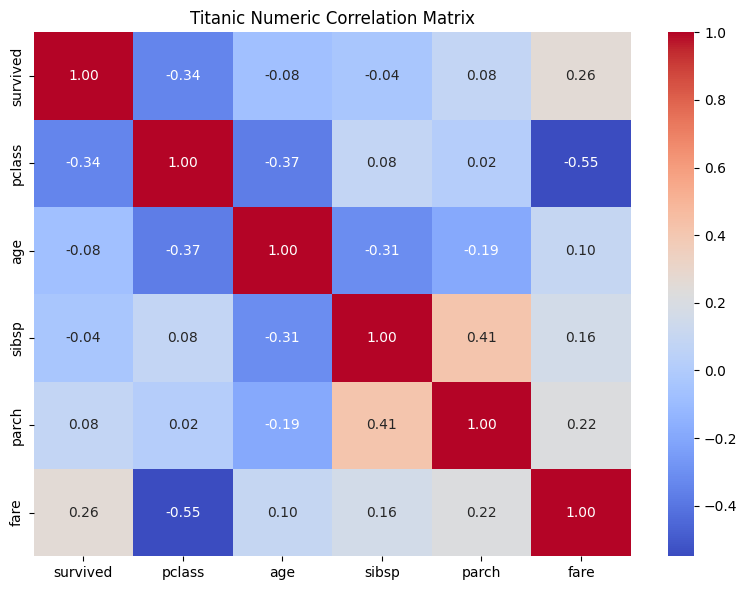

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Numeric Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
corr_abs = correlation_matrix.abs()

pairs = []

for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):

        col1 = corr_abs.columns[i]
        col2 = corr_abs.columns[j]

        pairs.append(
            (
                col1,
                col2,
                correlation_matrix.loc[col1, col2],
                abs(correlation_matrix.loc[col1, col2])
            )
        )

pairs = sorted(
    pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Two strongest correlations:")

for pair in pairs[:2]:
    print(pair)

Two strongest correlations:
('pclass', 'fare', np.float64(-0.5494996199439076), np.float64(0.5494996199439076))
('sibsp', 'parch', np.float64(0.41483769862015624), np.float64(0.41483769862015624))


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

eda_scaled = df[["age", "fare"]].copy()

eda_scaled[["age", "fare"]] = scaler.fit_transform(
    eda_scaled
)

print("Before scaling:")
print(df[["age", "fare"]].mean())
print(df[["age", "fare"]].std())

print("\nAfter scaling:")
print(eda_scaled.mean())
print(eda_scaled.std())

Before scaling:
age     29.699118
fare    32.204208
dtype: float64
age     14.526497
fare    49.693429
dtype: float64

After scaling:
age     2.388379e-16
fare    3.987333e-18
dtype: float64
age     1.000701
fare    1.000562
dtype: float64
